في هذا الملف سوف يتم عمل نموذج التنبؤ بمدى تدهور اداء الطائرات و سوف يتم تقسيم الموضوع له عدة اجزاء لكي يكون اكثر تنظيم
*   تعريف النموذج
*   استكشاف البيانات
* اختبار النموذج
*   عمل نموذج التنبؤ
*   تنظيف البيانات
















---


---


# =======================   تعريف نموذج =======================


---


---




متطلبات المهمةالغرض العام من المشروع
يهدف مشروعي إلى بناء نموذج ذكاء اصطناعي متطور يعمل على التنبؤ بمدى تدهور أداء الطائرات عند حدوث عطل مفاجئ في أحد محركاتها أثناء الطيران حيث يقوم النموذج بحساب نسبة العجز في قدرة الطائرة والارتفاع بناء على مواصفاتها الهندسية والتقنية مما يساعدني في تحديد الطائرات التي قد تواجه خطورة عالية لضمان سلامة الركاب.
المتطلبات الوظيفية الخاصة بالنموذج






* توفير تقدير دقيق لمدى تدهور قدرة الطائرة على الارتفاع عند تعطل المحرك لضمان سلامة الطيران في حالات الطوارئ

* تحسين كفاءة اتخاذ القرار للطيارين عبر التنبؤ المسبق بقدرة الطائرة على تجاوز العوائق الطبيعية مثل الجبال
* خفض احتمالات وقوع الحوادث الجوية من خلال تحديد الطائرات ذات هوامش الأمان المنخفضة في الأداء الاضطراري


*  المساهمة في الاستدامة التشغيلية لشركات الطيران عبر تقليل المخاطر والمحافظة على معايير السلامة العالمية



---



In [180]:
# (زي Excel)هاي المكتبة بستخدمها عشان اتعامل مع البيانات الجدولية
# اعدل اعمدة، افلتر بيانات، ارتبها و كل شغل البيانات الاساسي فيها
import pandas as pd

# هاي مكتبة العمليات الرياضية والحسابات
# بستخدمها للارقام و المصفوفات و العمليات الحسابية السريعة  والقيم العشوائية
import numpy as np

# هاي بستخدمها عشان اتعامل مع الوقت والتاريخ
# يعني لما بدي اعرف تاريخ اليوم او اسجل وقت حفظ النموذج
from datetime import datetime

# هاي خاصة بجوجل كولاب
# drive عشان اوصل لجوجل درايف تبعي
# files عشان ارفع او انزل ملفات من الكولاب على جهازي
from google.colab import drive, files

# هاي بستخدمها عشان انسخ او انقل ملفات داخل النظام
# يعني لماانقل ملف من مكان لمكان او اعمل نسخة احتياطية
import shutil

# إضافة: استيراد مكتبات الـ ML عشان النموذج (ما كانت موجودة، بس ضرورية للتنبؤ)
# sklearn للنماذج والتقييم
from sklearn.model_selection import train_test_split  # عشان نقسم البيانات لتدريب واختبار
from sklearn.linear_model import LinearRegression  # نموذج ريجريشن خطي بسيط
from sklearn.preprocessing import StandardScaler  # عشان نعمل scaling للبيانات
from sklearn.metrics import mean_squared_error  # عشان نحسب MSE
from sklearn.neighbors import KNeighborsClassifier  # عشان KNN، رغم أنه classification، بس حافظت عليه
import joblib  # عشان نحفظ النموذج







---


---


# =======================   استكشاف البيانات =======================


---


---




In [181]:
# استخدمت اول اشي
#عشان اعرف عدد الصفوف وعدد الاعمدة الموجودة عندي داخل الجدول يعني كم سجل وكم خاصية رح اشتغل عليهم
df.shape

(861, 22)

In [182]:
#   بعد ما عرفت حجم البيانات لازم اعرف نوع كل عمود عشان هيك استخدمت
df.dtypes
# عشان اشوف هل البيانات ارقام ولا نصوص ولا تواريخ لان نوع البيانات بفرق معي اثناء التنظيف وبناء النموذج

,0
Model,object
Company,object
Engine_Type,object
HP_or_lbs_thr_ea_engine,float64
Max_speed_Knots,float64
Rcmnd_cruise_Knots,float64
Stall_Knots_dirty,float64
Fuel_gal_lbs,float64
All_eng_service_ceiling,float64
Eng_out_service_ceiling,float64


In [183]:
# بعدها احتجت اعرف اسماء الاعمدة استخدمت
df.columns
# عشان اشوف كل اسماء الخصائص الموجودة واتاكد من كتابتها صح لما استخدمها بالكود

Index(['Model', 'Company', 'Engine_Type', 'HP_or_lbs_thr_ea_engine',
       'Max_speed_Knots', 'Rcmnd_cruise_Knots', 'Stall_Knots_dirty',
       'Fuel_gal_lbs', 'All_eng_service_ceiling', 'Eng_out_service_ceiling',
       'All_eng_rate_of_climb', 'Eng_out_rate_of_climb', 'Takeoff_over_50ft',
       'Takeoff_ground_run', 'Landing_over_50ft', 'Landing_ground_roll',
       'Gross_weight_lbs', 'Empty_weight_lbs', 'Length_ft_in', 'Height_ft_in',
       'Wing_span_ft_in', 'Range_NM'],
      dtype='object')

In [184]:
# بعدين استخدمت
df.info()
# عشان يعطيني معلومات عامة عن البيانات مثل عدد القيم غير الفارغة بكل عمود ونوع البيانات وبهالطريقة بقدر اعرف اذا عندي بيانات ناقصة

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Model                    861 non-null    object 
 1   Company                  861 non-null    object 
 2   Engine_Type              861 non-null    object 
 3   HP_or_lbs_thr_ea_engine  861 non-null    float64
 4   Max_speed_Knots          861 non-null    float64
 5   Rcmnd_cruise_Knots       861 non-null    float64
 6   Stall_Knots_dirty        861 non-null    float64
 7   Fuel_gal_lbs             861 non-null    float64
 8   All_eng_service_ceiling  861 non-null    float64
 9   Eng_out_service_ceiling  861 non-null    float64
 10  All_eng_rate_of_climb    861 non-null    float64
 11  Eng_out_rate_of_climb    861 non-null    float64
 12  Takeoff_over_50ft        861 non-null    float64
 13  Takeoff_ground_run       861 non-null    float64
 14  Landing_over_50ft        8

In [185]:
# بعدها تاكدت من وجود بيانات ناقصة باستخدام
df.isnull().sum()
#وهذا يعطيني عدد القيم الفارغة بكل عمود عشان اعرف اي اعمدة تحتاج تنظيف او تعويض

,0
Model,0
Company,0
Engine_Type,0
HP_or_lbs_thr_ea_engine,0
Max_speed_Knots,0
Rcmnd_cruise_Knots,0
Stall_Knots_dirty,0
Fuel_gal_lbs,0
All_eng_service_ceiling,0
Eng_out_service_ceiling,0


In [186]:
# بعدين تاكدت اذا في بيانات مكررة باستخدام
df.duplicated().sum()
#عشان اعرف كم سجل مكرر موجود واقرر اذا لازم احذفه

np.int64(0)

In [187]:
# بعدها استخدمت
df.head()
#حتى اشوف اول 5 صفوف من البيانات عشان آخذ فكرة سريعة عن شكل الجدول

,Model,Company,Engine_Type,HP_or_lbs_thr_ea_engine,Max_speed_Knots,Rcmnd_cruise_Knots,Stall_Knots_dirty,Fuel_gal_lbs,All_eng_service_ceiling,Eng_out_service_ceiling,...,Takeoff_over_50ft,Takeoff_ground_run,Landing_over_50ft,Landing_ground_roll,Gross_weight_lbs,Empty_weight_lbs,Length_ft_in,Height_ft_in,Wing_span_ft_in,Range_NM
0,15 AC Sedan,Aeronca,Piston,145.0,104.0,91.0,46.0,36.0,13000.0,16500.0,...,900.0,1160.0,1300.0,960.0,2050.0,1180.0,253.0,237.5,375.0,370.0
1,11 CC Super Chief,Aeronca,Piston,85.0,89.0,83.0,44.0,15.0,12300.0,16500.0,...,720.0,1160.0,800.0,960.0,1350.0,820.0,207.0,237.5,361.0,190.0
2,7 CCM Champ,Aeronca,Piston,90.0,90.0,78.0,37.0,19.0,16000.0,16500.0,...,475.0,1160.0,850.0,960.0,1300.0,810.0,215.0,237.5,350.0,210.0
3,7 DC Champ,Aeronca,Piston,85.0,88.0,78.0,37.0,19.0,13000.0,16500.0,...,500.0,1160.0,850.0,960.0,1300.0,800.0,215.0,237.5,350.0,210.0
4,7 AC Champ,Aeronca,Piston,65.0,83.0,74.0,33.0,14.0,12500.0,16500.0,...,632.0,1160.0,885.0,960.0,1220.0,740.0,215.0,237.5,350.0,175.0


In [188]:
# وبعدين استخدمت
df.tail()
#عشان اشوف آخر 5 صفوف واتاكد إنه ما في مشكلة في نهاية البيانات

,Model,Company,Engine_Type,HP_or_lbs_thr_ea_engine,Max_speed_Knots,Rcmnd_cruise_Knots,Stall_Knots_dirty,Fuel_gal_lbs,All_eng_service_ceiling,Eng_out_service_ceiling,...,Takeoff_over_50ft,Takeoff_ground_run,Landing_over_50ft,Landing_ground_roll,Gross_weight_lbs,Empty_weight_lbs,Length_ft_in,Height_ft_in,Wing_span_ft_in,Range_NM
856,500 A,Twin Commander AC,Piston,260.0,198.0,190.0,54.0,156.0,22500.0,7850.0,...,1210.0,970.0,1150.0,865.0,6250.0,4255.0,351.0,145.0,495.0,957.0
857,500,Twin Commander AC,Piston,250.0,190.0,178.0,55.0,156.0,22500.0,7150.0,...,1250.0,1000.0,1350.0,950.0,6000.0,3850.0,351.0,145.0,490.0,957.0
858,520,Twin Commander AC,Piston,260.0,183.0,171.0,52.0,150.0,24000.0,8500.0,...,1100.0,950.0,1050.0,900.0,5500.0,3800.0,355.0,145.0,441.0,1000.0
859,2180,Varga,Piston,180.0,130.0,116.0,45.0,33.0,22000.0,16500.0,...,1600.0,1160.0,1400.0,960.0,1817.0,1175.0,212.0,237.5,300.0,365.0
860,2150A Kachina,Varga,Piston,150.0,117.0,104.0,45.0,33.0,22000.0,16500.0,...,1600.0,1160.0,1400.0,960.0,1817.0,1125.0,212.0,237.5,300.0,380.0


In [189]:
#و اخر اشي استخدمتو
df.sample(10)
# حتى اعرض 10صفوف عشوائية من البيانات وهاي طريقة افضل لفهم تنوع البيانات بدل ما اشوف اول الصفوف فقط

,Model,Company,Engine_Type,HP_or_lbs_thr_ea_engine,Max_speed_Knots,Rcmnd_cruise_Knots,Stall_Knots_dirty,Fuel_gal_lbs,All_eng_service_ceiling,Eng_out_service_ceiling,...,Takeoff_over_50ft,Takeoff_ground_run,Landing_over_50ft,Landing_ground_roll,Gross_weight_lbs,Empty_weight_lbs,Length_ft_in,Height_ft_in,Wing_span_ft_in,Range_NM
4,7 AC Champ,Aeronca,Piston,65.0,83.00,74.0,33.0,14.0,12500.0,16500.0,...,632.0,1160.0,885.0,960.0,1220.0,740.0,215.0,237.5,350.0,175.0
163,23 Musketeer,Beechcraft Hawker Beechcraft,Piston,160.0,123.00,111.0,52.0,60.0,13500.0,16500.0,...,1275.0,925.0,1260.0,640.0,2300.0,1300.0,251.0,237.5,327.0,800.0
429,Columbia 400 LC-41,Columbia Aircraft Mfg,Piston,310.0,235.00,181.0,57.0,106.0,25000.0,16500.0,...,1250.0,700.0,2350.0,1150.0,3600.0,2500.0,252.0,9.0,358.0,1300.0
355,A188,A,B,300.0,192.00,175.0,300.0,131.0,123.0,50.0,...,1600.0,940.0,1400.0,970.0,610.0,1265.0,420.0,3300.0,1845.0,263.0
80,F90 King Air,Beechcraft Hawker Beechcraft,Propjet,750.0,267.00,261.0,77.0,470.0,29802.0,14419.0,...,2856.0,2090.0,2275.0,1194.0,10950.0,6549.0,3910.0,151.0,4511.0,1235.0
815,Piper PA-23-250 Aztec,Sierra Industries,Unknown,300.0,192.00,175.0,52.0,93.0,19100.0,16500.0,...,985.0,610.0,1270.0,500.0,3500.0,20.0,417.0,237.5,418.0,704.0
581,M-5-210C Lunar Rocket,Maule Air Inc,Piston,210.0,157.00,137.0,33.0,40.0,18000.0,16500.0,...,600.0,150.0,600.0,200.0,2300.0,1350.0,229.0,237.5,3010.0,345.0
247,Citationjet 525,Cessna Aircraft Company,Jet,1900.0,0.71,380.0,85.0,3220.0,41000.0,23000.0,...,3080.0,1160.0,2750.0,960.0,10400.0,6550.0,426.0,137.0,468.0,1485.0
804,Cessna 337 turbo,pressurized,Sierra Industries,300.0,192.00,175.0,61.0,40.0,19100.0,16500.0,...,1600.0,756.0,475.0,731.0,450.0,2800.0,22.0,237.5,418.0,704.0
479,DW-1 ag plane,Eagle,Piston,300.0,100.00,57.0,48.0,40.0,19100.0,16500.0,...,2257.0,1421.0,1400.0,960.0,5400.0,2650.0,276.0,237.5,550.0,704.0




---


قبل البدء بعملية تنظيف البيانات قمت بمرحلة استكشاف البيانات بهدف فهم طبيعة البيانات وبنيتها بشكل كامل حيث تساعد هذه المرحلة في التعرف على حجم البيانات وعدد الأعمدة وأنواعها واكتشاف القيم الناقصة والقيم الشاذة والبيانات المكررة إضافة إلى فهم توزيع القيم الإحصائي مما يتيح لي تحديد خطة تنظيف دقيقة  مبنية على فهم حقيقي للبيانات وليس على افتراضات عشوائية وبالتالي يساهم ذلك في تحسين جودة البيانات ورفع دقة نموذج التنبؤ وضمان الحصول على نتائج أكثر موثوقية عند بناء
نموذج الذكاء الاصطناعي
---


---











---


---


# =======================   تنظيف البيانات =======================


---


---




In [190]:
# 1. مكتبة pandas للتعامل مع الجداول
import pandas as pd
# 2. مكتبة numpy للعمليات الحسابية والقيم الفارغة
import numpy as np
# 3. مكتبة الوقت والتاريخ
from datetime import datetime
# 4. أدوات جوجل كولاب للتعامل مع الملفات والدرايف
from google.colab import drive, files
# 5. مكتبة shutil لنقل ونسخ الملفات
import shutil
# 6. مكتبة re للتعامل مع النصوص المتقدمة (Regex)
import re


path = "/content/drive/MyDrive/Aircraft Performance (Aircraft Bluebook)/Aiplane_BlueBook-5.xls"

# ربط جوجل درايف بالكولاب للوصول للملفات
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [191]:

# قائمة الرموز والكلمات الغريبة اللي بدنا نعتبرها "فاضية" (NaN)
bad_tokens = [
    "#NAME?", "#DIV/0!", "#VALUE!", "#REF!", "#N/A",
    "####", "#####", "######", "#######",
    "N/A", "NA", "na", "null", "None", "-", "--", "—", "_", ""
]

In [202]:
def clean_cell(x):
    # إذا كانت الخلية أصلاً فاضية
    if pd.isna(x): return np.nan

    # تحويل النص لإزالة المسافات الزائدة
    s = str(x).strip()

    # إذا كانت الخلية تحتوي على أحد الرموز القذرة
    if s in bad_tokens: return np.nan

    # توحيد علامات الاقتباس وتصحيح المسافات بين الكلمات
    s = (s.replace("“", '"').replace("”", '"')
          .replace("‘", "'").replace("’", "'").replace("`", "'"))
    s = " ".join(s.split())

    # إذا كانت الخلية كلها عبارة عن سطر مربعات #######
    if set(s) == {"#"}: return np.nan

    return s

# تطبيق التنظيف على كل خلية في الجدول
df = df.applymap(clean_cell)

,Model,Company,Engine_Type,HP_or_lbs_thr_ea_engine,Max_speed_Knots,Rcmnd_cruise_Knots,Stall_Knots_dirty,Fuel_gal_lbs,All_eng_service_ceiling,Eng_out_service_ceiling,...,Takeoff_over_50ft,Takeoff_ground_run,Landing_over_50ft,Landing_ground_roll,Gross_weight_lbs,Empty_weight_lbs,Length_ft_in,Height_ft_in,Wing_span_ft_in,Range_NM
0,15 AC Sedan,Aeronca,Piston,145.0,104.0,91.0,46.0,36.0,13000.0,16500.0,...,900.0,1160.0,1300.0,960.0,2050.0,1180.0,253.0,237.5,375.0,370.0
1,11 CC Super Chief,Aeronca,Piston,85.0,89.0,83.0,44.0,15.0,12300.0,16500.0,...,720.0,1160.0,800.0,960.0,1350.0,820.0,207.0,237.5,361.0,190.0
2,7 CCM Champ,Aeronca,Piston,90.0,90.0,78.0,37.0,19.0,16000.0,16500.0,...,475.0,1160.0,850.0,960.0,1300.0,810.0,215.0,237.5,350.0,210.0
3,7 DC Champ,Aeronca,Piston,85.0,88.0,78.0,37.0,19.0,13000.0,16500.0,...,500.0,1160.0,850.0,960.0,1300.0,800.0,215.0,237.5,350.0,210.0
4,7 AC Champ,Aeronca,Piston,65.0,83.0,74.0,33.0,14.0,12500.0,16500.0,...,632.0,1160.0,885.0,960.0,1220.0,740.0,215.0,237.5,350.0,175.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,500 A,Twin Commander AC,Piston,260.0,198.0,190.0,54.0,156.0,22500.0,7850.0,...,1210.0,970.0,1150.0,865.0,6250.0,4255.0,351.0,145.0,495.0,957.0
857,500,Twin Commander AC,Piston,250.0,190.0,178.0,55.0,156.0,22500.0,7150.0,...,1250.0,1000.0,1350.0,950.0,6000.0,3850.0,351.0,145.0,490.0,957.0
858,520,Twin Commander AC,Piston,260.0,183.0,171.0,52.0,150.0,24000.0,8500.0,...,1100.0,950.0,1050.0,900.0,5500.0,3800.0,355.0,145.0,441.0,1000.0
859,2180,Varga,Piston,180.0,130.0,116.0,45.0,33.0,22000.0,16500.0,...,1600.0,1160.0,1400.0,960.0,1817.0,1175.0,212.0,237.5,300.0,365.0


In [193]:
# تحديد الأعمدة وحذف الأعمدة غير المهمة (مثل C1, C2)
cols = df.columns.tolist()
drop_cols = [c for c in df.columns if str(c).strip().lower() in ["c1", "c2"]]
df = df.drop(columns=drop_cols, errors="ignore")

# تنظيف أسماء الأعمدة (إزالة رموز، تبديل المسافة بـ _ )
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace('"', '', regex=False)
    .str.replace("'", '', regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^A-Za-z0-9_]", "", regex=True)
)

# تحديث قوائم الأعمدة (أول 3 نصية والباقي رقمية)
cols = df.columns.tolist()
text_cols = cols[:3]
num_cols  = cols[3:]

In [194]:
# 1. تنظيف الأعمدة النصية (إزالة أي رمز مش حرف أو رقم)
for c in text_cols:
    df[c] = (df[c].astype(str).str.strip()
             .str.replace(r"[^\w\s\-]", "", regex=True)
             .str.replace(r"\s+", " ", regex=True))
    df.loc[df[c].isin(["", "nan", "None"]), c] = np.nan

# 2. تنظيف الأعمدة الرقمية (استخراج الأرقام فقط وتحويل النوع لـ numeric)
for col in num_cols:
    if col in df.columns:
        df[col] = (df[col].astype(str)
                   .str.replace(",", "", regex=False)
                   .str.replace(r"[^0-9\.\-]+", "", regex=True))
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. إزالة الصفوف المكررة تماماً
df = df.drop_duplicates()

In [195]:
# تعبئة القيم المفقودة: النص بكلمة "Unknown" والأرقام بـ "الوسيط - Median"
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# حفظ النتيجة النهائية في ملف CSV
df.to_csv("Clean_Data_Aircraft_Performance.csv", index=False)
print(" تم تنظيف البيانات وحفظ الملف بنجاح!")

 تم تنظيف البيانات وحفظ الملف بنجاح!




---

بعد الانتهاء من مرحلة استكشاف البيانات سأبدأ الآن بعملية تنظيف البيانات وتهدف هذه المرحلة إلى معالجة القيم الناقصة وتصحيح القيم غير المنطقية وإزالة التكرار وتوحيد تنسيق البيانات وأنواعها وذلك لضمان أن تكون البيانات دقيقة ومنظمة وصالحة للاستخدام في بناء نموذج التنبؤ مما يساعد في تحسين أداء النموذج وتقليل الأخطاء ورفع موثوقية النتائج النهائية
---



---












---


---


# =======================   اعداد نموذج   =======================


---


---




In [196]:
# إضافة: استيراد مكتبات الـ ML والرسوم اللي مش موجودة في الاستيراد الأساسي
# sklearn للنماذج والتقييم والتقسيم
from sklearn.model_selection import train_test_split  # عشان نقسم البيانات لتدريب واختبار
from sklearn.linear_model import LinearRegression  # نموذج ريجريشن خطي بسيط
from sklearn.ensemble import RandomForestRegressor  # نموذج راندوم فورست للريجريشن
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier  # KNN للريجريشن والتصنيف
from sklearn.preprocessing import StandardScaler  # عشان نعمل scaling
from sklearn.metrics import mean_squared_error, accuracy_score  # عشان نحسب الخطأ والدقة
import matplotlib.pyplot as plt  # عشان الرسوم
import joblib  # عشان نحفظ النموذج

print("جميع المكتبات تم استيرادها بنجاح")

جميع المكتبات تم استيرادها بنجاح


In [197]:
# افترض إن df جاهزة بعد التنظيف (لو مش موجودة، شغل خلية التنظيف الأولى)
# إذا كان التنظيف حفظ الملف، نقراه هون
df = pd.read_csv("/content/drive/MyDrive/Aircraft Performance (Aircraft Bluebook)/Clean_Data_Aircraft_Performance.csv")  # نقرا البيانات النظيفة اللي حفظناها

# هون بنحدد الأعمدة الرقمية اللي رح نستخدمها كـ features (X)
numeric_columns = ['HP_or_lbs_thr_ea_engine', 'Max_speed_Knots', 'Rcmnd_cruise_Knots', 'Stall_Knots_dirty',
                   'Fuel_gal_lbs', 'All_eng_service_ceiling', 'All_eng_rate_of_climb', 'Eng_out_rate_of_climb',
                   'Takeoff_over_50ft', 'Landing_over_50ft', 'Gross_weight_lbs', 'Empty_weight_lbs', 'Range_NM']

# هون بنحول الأعمدة لأرقام إذا لزم (من التنظيف السابق)
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # تحول لأرقام، لو خطأ يحط NaN

# التعامل مع القيم الناقصة مرة تانية لو في (من التنظيف)
df.fillna(df.mean(numeric_only=True), inplace=True)

# إعداد الـ features (X) والـ target (y)
# نفترض 'Eng_out_service_ceiling' هو الـ target (تدهور الارتفاع عند تعطل المحرك)
X = df.select_dtypes(include=['float64', 'int64']).drop('Eng_out_service_ceiling', axis=1, errors='ignore')  # كل الأعمدة الرقمية إلا الـ target
y = df['Eng_out_service_ceiling']  # الـ target (يمكن تغييره لو بدك target تاني زي فرق الارتفاع)

# تقسيم البيانات لتدريب (80%) واختبار (20%) – مشترك
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (تطبيع البيانات) عشان النموذج يشتغل أحسن، خاصة مع KNN و Linear
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # نتعلم التطبيع من التدريب
X_test_scaled = scaler.transform(X_test)  # نطبق على الاختبار

Mean Squared Error (MSE): 32182934.042749543
MSE = 32182934.04  (كلما كان أصغر → النموذج أدق)


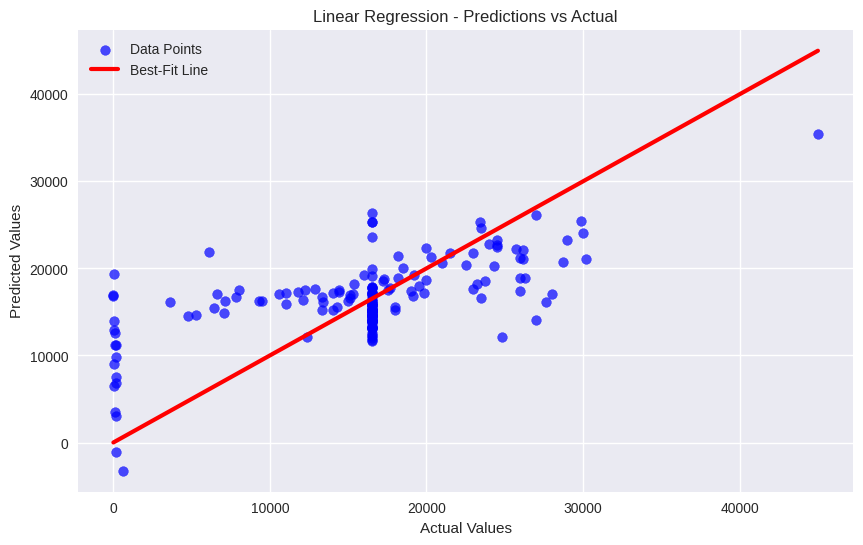

In [198]:
# ────────────── Linear Regression ──────────────

# تدريب النموذج
lr = LinearRegression()  # بنعمل instance من النموذج
lr.fit(X_train_scaled, y_train)  # ندرب النموذج على البيانات المقسمة والمطبقة

# اختبار (predict)
y_pred = lr.predict(X_test_scaled)  # predict بالنموذج الخطي (استخدم scaled عشان يطابق التدريب)

# تقييم (من الكود الأصلي، حافظت عليه كامل)
mse = mean_squared_error(y_test, y_pred)  # نحسب الخطأ التربيعي المتوسط (MSE) للريجريشن
print("Mean Squared Error (MSE):", mse)  # طباعة الـ MSE
print(f"MSE = {mse:.2f}  (كلما كان أصغر → النموذج أدق)")  # شرح بسيط

# رسم (scatter plot للتنبؤات مقابل الحقيقي، زي في الملف الأصلي)
plt.figure(figsize=(10, 6))  # حجم الرسم
plt.scatter(y_test, y_pred, color='blue', label='Data Points', alpha=0.7)  # نقاط التنبؤ مقابل الحقيقي
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=3, label='Best-Fit Line')  # خط مثالي
plt.xlabel('Actual Values')  # محور X
plt.ylabel('Predicted Values')  # محور Y
plt.title('Linear Regression - Predictions vs Actual')  # عنوان
plt.legend()  # ليجند
plt.grid(True)  # جريد
plt.show()  # عرض الرسم


Mean Squared Error (MSE): 6604832.441194218
MSE = 6604832.44  (كلما كان أصغر → النموذج أدق)


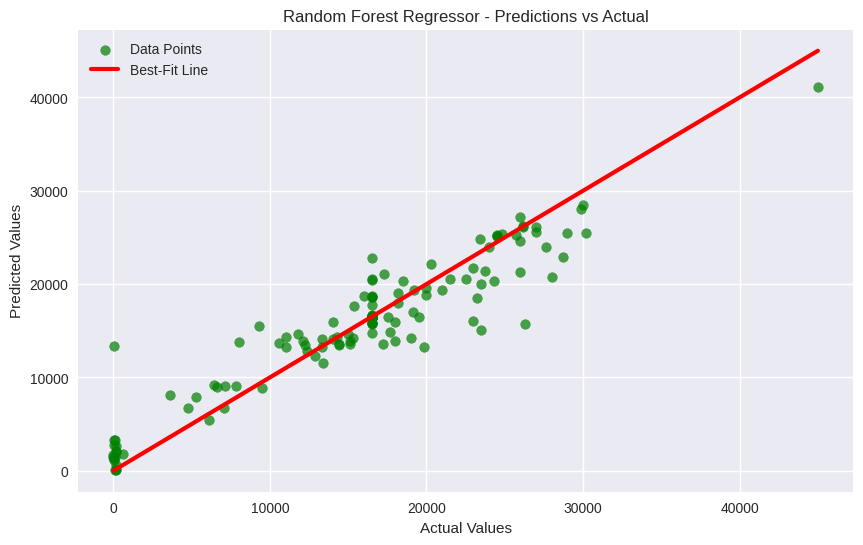

In [199]:
# ────────────── Random Forest Regressor ──────────────

# تدريب النموذج
rf = RandomForestRegressor(n_estimators=100, random_state=42)  # بنعمل instance من النموذج (100 شجرة)
rf.fit(X_train, y_train)  # ندرب النموذج على البيانات المقسمة (ما يحتاج scaling)

# اختبار (predict)
y_pred = rf.predict(X_test)  # predict بالنموذج (استخدم X_test العادي)

# تقييم (من الكود الأصلي، حافظت عليه كامل)
mse = mean_squared_error(y_test, y_pred)  # نحسب الخطأ التربيعي المتوسط (MSE) للريجريشن
print("Mean Squared Error (MSE):", mse)  # طباعة الـ MSE
print(f"MSE = {mse:.2f}  (كلما كان أصغر → النموذج أدق)")  # شرح بسيط

# رسم (scatter plot للتنبؤات مقابل الحقيقي، زي في الملف الأصلي)
plt.figure(figsize=(10, 6))  # حجم الرسم
plt.scatter(y_test, y_pred, color='green', label='Data Points', alpha=0.7)  # نقاط التنبؤ مقابل الحقيقي
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=3, label='Best-Fit Line')  # خط مثالي
plt.xlabel('Actual Values')  # محور X
plt.ylabel('Predicted Values')  # محور Y
plt.title('Random Forest Regressor - Predictions vs Actual')  # عنوان
plt.legend()  # ليجند
plt.grid(True)  # جريد
plt.show()  # عرض الرسم


Mean Squared Error (MSE): 14173258.368786126
MSE = 14173258.37  (كلما كان أصغر → النموذج أدق)
 KNN Classifier Accuracy: 0.4046


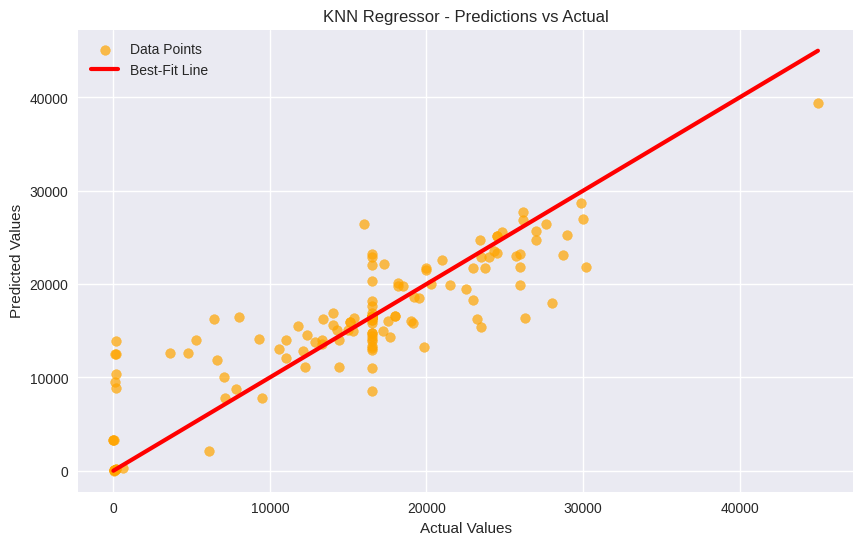

In [200]:
# ────────────── KNN Regressor ──────────────

# تدريب النموذج
knn_reg = KNeighborsRegressor(n_neighbors=5)  # بنعمل instance من النموذج (5 جيران)
knn_reg.fit(X_train_scaled, y_train)  # ندرب النموذج على البيانات المقسمة والمطبقة

# KNN Classifier (اختياري، من الكود الأصلي، حافظت عليه كامل مع تصحيح)
knn_clf = KNeighborsClassifier(n_neighbors=5)  # KNN للتصنيف
y_train_b = y_train.astype(int)  # تصحيح: نحول y_train لـ int عشان التصنيف (لو كان رقمي مستمر)
knn_clf.fit(X_train_scaled, y_train_b)  # ندرب

# اختبار (predict)
y_pred = knn_reg.predict(X_test_scaled)  # predict بالنموذج (استخدم scaled عشان يطابق التدريب)

# تقييم (من الكود الأصلي، حافظت عليه كامل)
mse = mean_squared_error(y_test, y_pred)  # نحسب الخطأ التربيعي المتوسط (MSE) للريجريشن
print("Mean Squared Error (MSE):", mse)  # طباعة الـ MSE
print(f"MSE = {mse:.2f}  (كلما كان أصغر → النموذج أدق)")  # شرح بسيط

# KNN Classifier Accuracy (من الكود الأصلي، مع تصحيح)
y_test_b = y_test.astype(int)  # تصحيح: نحول y_test لـ int عشان التصنيف
print(f" KNN Classifier Accuracy: {accuracy_score(y_test_b, knn_clf.predict(X_test_scaled)):.4f}")  # دقة التصنيف

# رسم (scatter plot للتنبؤات مقابل الحقيقي، زي في الملف الأصلي)
plt.figure(figsize=(10, 6))  # حجم الرسم
plt.scatter(y_test, y_pred, color='orange', label='Data Points', alpha=0.7)  # نقاط التنبؤ مقابل الحقيقي
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=3, label='Best-Fit Line')  # خط مثالي
plt.xlabel('Actual Values')  # محور X
plt.ylabel('Predicted Values')  # محور Y
plt.title('KNN Regressor - Predictions vs Actual')  # عنوان
plt.legend()  # ليجند
plt.grid(True)  # جريد
plt.show()  # عرض الرسم



In [201]:
import joblib
from google.colab import drive
drive.mount('/content/drive')
model = ...
joblib.dump(model, '/content/drive/MyDrive/V.0.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/V.0.pkl']